# Introduction

***TRIGGER WARNING:***

This notebook aims at creating a model to identify violent language expressed on the platform Tweeter (now X).

I believe violence has no place, anywhere, and it should be monitored in the social media community as violent language and cyber mobbing can scar one's self esteem and lead to extreme actions by the victim of such violence.

With this notebook I want to establish a model which identifies emotions and in case of violent language and reports it automatically to the operating team of the platform. The request is to have the user profile reviewed and see if there's the extreme to ban the profile permanently.

Please be aware that the content of the datasets used contains language and comments which might be disturbing to you due to their nature.

If you are sensitive to these topics, please avoid working with these data frames directly.

In [48]:
#Importing the required libraries

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import nlp
import tensorflow as tf
from transformers import pipeline, AutoTokenizer

## Data Prep and Cleaning

In [49]:
data = pd.read_csv('c:/Data_Science/IH_Notebooks/tweet_emotion_recognition/text.csv')
tweet_df = data.copy()

tweet_df.head()

,Unnamed: 0,text,label
0,0,i just feel really helpless and heavy hearted,4
1,1,ive enjoyed being able to slouch about relax a...,0
2,2,i gave up my internship with the dmrg and am f...,4
3,3,i dont know i feel so lost,0
4,4,i am a kindergarten teacher and i am thoroughl...,4


In [50]:
tweet_df = tweet_df.rename(columns={'Unnamed: 0' : 'index'})
tweet_df

,index,text,label
0,0,i just feel really helpless and heavy hearted,4
1,1,ive enjoyed being able to slouch about relax a...,0
2,2,i gave up my internship with the dmrg and am f...,4
3,3,i dont know i feel so lost,0
4,4,i am a kindergarten teacher and i am thoroughl...,4
...,...,...,...
416804,416804,i feel like telling these horny devils to find...,2
416805,416805,i began to realize that when i was feeling agi...,3
416806,416806,i feel very curious be why previous early dawn...,5
416807,416807,i feel that becuase of the tyranical nature of...,3


In [51]:
tweet_df.sample(10)

,index,text,label
110425,110425,i still feel weepy right now but i hope to lea...,0
290828,290828,im sure im not the only person who at this tim...,0
69171,69171,i feel too for me painting faces it s just the...,1
281731,281731,i feel to be the fake gay story,0
61081,61081,i feel kind of like im waking up from a long p...,1
173835,173835,i feel generally respected,1
61521,61521,i might feel distressed,4
158000,158000,i feel so rude when i click that reply button but,3
195239,195239,im excited to read the next installment as the...,0
130558,130558,i feel really irritated when such replies have...,3


In [52]:
emotions_df = tweet_df.copy()

emotions_map = {
    0 : 'Sadness',
    1 : 'Joy',
    2 : 'Love',
    3 : 'Anger',
    4 : 'Fear',
    5 : 'Surprise'
}

emotions_df['Emotion'] = emotions_df['label'].map(emotions_map)

emotions_df

,index,text,label,Emotion
0,0,i just feel really helpless and heavy hearted,4,Fear
1,1,ive enjoyed being able to slouch about relax a...,0,Sadness
2,2,i gave up my internship with the dmrg and am f...,4,Fear
3,3,i dont know i feel so lost,0,Sadness
4,4,i am a kindergarten teacher and i am thoroughl...,4,Fear
...,...,...,...,...
416804,416804,i feel like telling these horny devils to find...,2,Love
416805,416805,i began to realize that when i was feeling agi...,3,Anger
416806,416806,i feel very curious be why previous early dawn...,5,Surprise
416807,416807,i feel that becuase of the tyranical nature of...,3,Anger


In [53]:
emotions_distribution = emotions_df.groupby('Emotion')['index'].count()
emotions_distribution

Emotion
Anger        57317
Fear         47712
Joy         141067
Love         34554
Sadness     121187
Surprise     14972
Name: index, dtype: int64

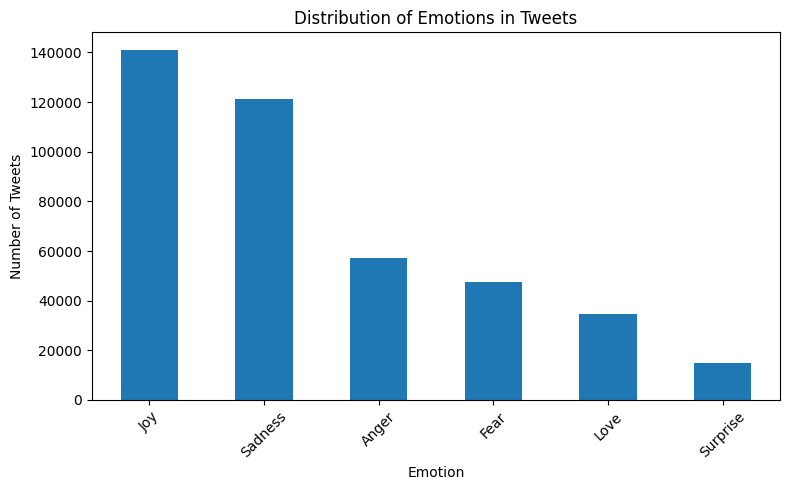

In [54]:
# Assuming emotions_distribution is already created
plt.figure(figsize=(8, 5))
emotions_distribution.sort_values(ascending=False).plot(kind='bar')

plt.title('Distribution of Emotions in Tweets')
plt.xlabel('Emotion')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [55]:
hate_df = pd.read_csv('c:/Data_Science/IH_Notebooks/tweet_emotion_recognition/labeled_data.csv')
violence_df = pd.read_csv('c:/Data_Science/IH_Notebooks/tweet_emotion_recognition/Train.csv')

In [56]:
hate_df.columns

Index(['Unnamed: 0', 'count', 'hate_speech', 'offensive_language', 'neither',
       'class', 'tweet'],
      dtype='object')

In [57]:
hate_df.sample(10)

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
10668,10948,3,0,3,0,1,I like how cays mf ass favorited my tweet but ...
13473,13804,3,0,3,0,1,Now I don't even want to do anything. Son of a...
17654,18054,3,1,2,0,1,RT @TheDouch3: Tweeting about ur boyfriend won...
2323,2369,9,0,0,9,2,@1usagrunt. I wonder what Charlie Brown would ...
24714,25227,3,0,0,3,2,wondertrade is the best pokemon feature ever. ...
16874,17260,3,0,0,3,2,RT @PatVPeters: Texas ranchers: Terrorists rep...
16766,17151,3,0,3,0,1,RT @O_ShitItsLaura: With ma bitch c: @yadirasa...
4465,4597,6,0,6,0,1,@RAEPaelMunturo apparently not many bitches ha...
14529,14878,3,2,0,1,0,RT @Buckm00se: kill this beaner
1063,1086,3,0,3,0,1,&#128588;RT @Ke2yourheart I don't want my man ...


In [58]:
hate_df = hate_df.drop(columns= ['Unnamed: 0', 'count', 'offensive_language', 'neither', 'hate_speech'])
hate_df

,class,tweet
0,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...
...,...,...
24778,1,you's a muthaf***in lie &#8220;@LifeAsKing: @2...
24779,2,"you've gone and broke the wrong heart baby, an..."
24780,1,young buck wanna eat!!.. dat nigguh like I ain...
24781,1,youu got wild bitches tellin you lies


In [59]:
violence_df = violence_df.drop(columns='Tweet_ID')

violence_df

,tweet,type
0,Had a dream i got raped last night. By a guy i...,sexual_violence
1,he thought the word raped means sex and told m...,sexual_violence
2,She NOT TALKING TO ME I WAS RAPED BY 2 MEN 1 M...,sexual_violence
3,I was sexually abused for 3 years at age 4 to ...,sexual_violence
4,Chessy Prout can do better by telling the trut...,sexual_violence
...,...,...
39645,"ENTRY 1299: 21F. 23M, BF’s cousin. Got drunk o...",sexual_violence
39646,So you’re telling me Emmanuel Macron was groom...,sexual_violence
39647,"My wife regularly beats me, I get dirty slaps ...",Physical_violence
39648,Me: Hey babe! Police officer boyfriend: is tha...,sexual_violence


In [60]:
tweet_df = tweet_df.drop(columns= 'index')
tweet_df

,text,label
0,i just feel really helpless and heavy hearted,4
1,ive enjoyed being able to slouch about relax a...,0
2,i gave up my internship with the dmrg and am f...,4
3,i dont know i feel so lost,0
4,i am a kindergarten teacher and i am thoroughl...,4
...,...,...
416804,i feel like telling these horny devils to find...,2
416805,i began to realize that when i was feeling agi...,3
416806,i feel very curious be why previous early dawn...,5
416807,i feel that becuase of the tyranical nature of...,3


In [61]:
emotions_df = emotions_df.drop(columns= 'index')
emotions_df

,text,label,Emotion
0,i just feel really helpless and heavy hearted,4,Fear
1,ive enjoyed being able to slouch about relax a...,0,Sadness
2,i gave up my internship with the dmrg and am f...,4,Fear
3,i dont know i feel so lost,0,Sadness
4,i am a kindergarten teacher and i am thoroughl...,4,Fear
...,...,...,...
416804,i feel like telling these horny devils to find...,2,Love
416805,i began to realize that when i was feeling agi...,3,Anger
416806,i feel very curious be why previous early dawn...,5,Surprise
416807,i feel that becuase of the tyranical nature of...,3,Anger


Now that I have all of the dfs more aligned I'm going to map the hate and violence df to better match the emotions df.

In [62]:
#these libraries are going to allow me to deal with the texts and also to prepare it for ML

import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords 

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Mirko\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [63]:
#the stopwords method removes words which hold small meaning such as 'the', 'it', 'a', etc.
##this is useful when working with ML models and texts to make the learning easier for the model
stop_words = set(stopwords.words('english'))

def text_cleaning(text):
    text = text.lower()
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'\brt\b', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = ' '.join(word for word in text.split() if word not in stop_words)
    
    return text

        


In [64]:
hate_df['clean text'] = hate_df['tweet'].apply(text_cleaning)

In [65]:
violence_df['clean text'] = violence_df['tweet'].apply(text_cleaning)

In [66]:
emotions_df['clean text'] = emotions_df['text'].apply(text_cleaning)

In [67]:
hate_df = hate_df.drop(columns= 'tweet')

In [68]:
violence_df = violence_df.drop(columns='tweet')

In [69]:
hate_df = hate_df.rename(columns={'clean text' : 'text'})

In [70]:
violence_df = violence_df.rename(columns={'clean text' : 'text'})

In [71]:
emotions_df = emotions_df.drop(columns='text')

emotions_df = emotions_df.rename(columns={'clean text' : 'text'})

In [72]:
violence_df

,type,text
0,sexual_violence,dream got raped last night guy work actually g...
1,sexual_violence,thought word raped means sex told saw dogs rap...
2,sexual_violence,talking raped men molested jail nother charge ...
3,sexual_violence,sexually abused years age one believed raped b...
4,sexual_violence,chessy prout better telling truth selling owen...
...,...,...
39645,sexual_violence,entry f bfs cousin got drunk halloween liked h...
39646,sexual_violence,youre telling emmanuel macron groomed maybe ev...
39647,Physical_violence,wife regularly beats get dirty slaps husband t...
39648,sexual_violence,hey babe police officer boyfriend meyes babe g...


In [73]:
violence_df['type'].value_counts()

type
sexual_violence                 32648
Physical_violence                5946
emotional_violence                651
economic_violence                 217
Harmful_Traditional_practice      188
Name: count, dtype: int64

I'm going to remove the emotional/economical/traditional violence from the df as I don't have enough data to build a model which is going to recognize this type of violence.

In [74]:
violence_df = violence_df.loc[(violence_df['type'] == 'sexual_violence') | (violence_df['type'] == 'Physical_violence')]
violence_df

,type,text
0,sexual_violence,dream got raped last night guy work actually g...
1,sexual_violence,thought word raped means sex told saw dogs rap...
2,sexual_violence,talking raped men molested jail nother charge ...
3,sexual_violence,sexually abused years age one believed raped b...
4,sexual_violence,chessy prout better telling truth selling owen...
...,...,...
39645,sexual_violence,entry f bfs cousin got drunk halloween liked h...
39646,sexual_violence,youre telling emmanuel macron groomed maybe ev...
39647,Physical_violence,wife regularly beats get dirty slaps husband t...
39648,sexual_violence,hey babe police officer boyfriend meyes babe g...


In [75]:
#moving the type to the right
type_placeholder = violence_df.pop('type')
violence_df['type'] = type_placeholder
violence_df

,text,type
0,dream got raped last night guy work actually g...,sexual_violence
1,thought word raped means sex told saw dogs rap...,sexual_violence
2,talking raped men molested jail nother charge ...,sexual_violence
3,sexually abused years age one believed raped b...,sexual_violence
4,chessy prout better telling truth selling owen...,sexual_violence
...,...,...
39645,entry f bfs cousin got drunk halloween liked h...,sexual_violence
39646,youre telling emmanuel macron groomed maybe ev...,sexual_violence
39647,wife regularly beats get dirty slaps husband t...,Physical_violence
39648,hey babe police officer boyfriend meyes babe g...,sexual_violence


In [76]:
hate_df

,class,text
0,2,woman shouldnt complain cleaning house amp man...
1,1,boy dats coldtyga dwn bad cuffin dat hoe st place
2,1,dawg ever fuck bitch start cry confused shit
3,1,look like tranny
4,1,shit hear might true might faker bitch told ya
...,...,...
24778,1,yous muthafin lie right tl trash mine bible sc...
24779,2,youve gone broke wrong heart baby drove rednec...
24780,1,young buck wanna eat dat nigguh like aint fuck...
24781,1,youu got wild bitches tellin lies


In [77]:
#moving class to the right
class_placeholder = hate_df.pop('class')
hate_df['class'] = class_placeholder
hate_df

,text,class
0,woman shouldnt complain cleaning house amp man...,2
1,boy dats coldtyga dwn bad cuffin dat hoe st place,1
2,dawg ever fuck bitch start cry confused shit,1
3,look like tranny,1
4,shit hear might true might faker bitch told ya,1
...,...,...
24778,yous muthafin lie right tl trash mine bible sc...,1
24779,youve gone broke wrong heart baby drove rednec...,2
24780,young buck wanna eat dat nigguh like aint fuck...,1
24781,youu got wild bitches tellin lies,1


In [78]:
hate_df['class'].value_counts()

class
1    19190
2     4163
0     1430
Name: count, dtype: int64

In [79]:
#removing the class 0 from hate_df

hate_df = hate_df.loc[(hate_df['class'] == 1) | (hate_df['class'] == 2)]
hate_df

,text,class
0,woman shouldnt complain cleaning house amp man...,2
1,boy dats coldtyga dwn bad cuffin dat hoe st place,1
2,dawg ever fuck bitch start cry confused shit,1
3,look like tranny,1
4,shit hear might true might faker bitch told ya,1
...,...,...
24778,yous muthafin lie right tl trash mine bible sc...,1
24779,youve gone broke wrong heart baby drove rednec...,2
24780,young buck wanna eat dat nigguh like aint fuck...,1
24781,youu got wild bitches tellin lies,1


In [80]:
emotions_df

,label,Emotion,text
0,4,Fear,feel really helpless heavy hearted
1,0,Sadness,ive enjoyed able slouch relax unwind frankly n...
2,4,Fear,gave internship dmrg feeling distraught
3,0,Sadness,dont know feel lost
4,4,Fear,kindergarten teacher thoroughly weary job take...
...,...,...,...
416804,2,Love,feel like telling horny devils find site suite...
416805,3,Anger,began realize feeling agitated restless would ...
416806,5,Surprise,feel curious previous early dawn time seek tro...
416807,3,Anger,feel becuase tyranical nature government el sa...


In [81]:
#moving label and emotion to the right

label_placeholder = emotions_df.pop('label')
emotions_df['label'] = label_placeholder

emotion_placeholder = emotions_df.pop('Emotion')
emotions_df['emotion'] = emotion_placeholder

emotions_df

,text,label,emotion
0,feel really helpless heavy hearted,4,Fear
1,ive enjoyed able slouch relax unwind frankly n...,0,Sadness
2,gave internship dmrg feeling distraught,4,Fear
3,dont know feel lost,0,Sadness
4,kindergarten teacher thoroughly weary job take...,4,Fear
...,...,...,...
416804,feel like telling horny devils find site suite...,2,Love
416805,began realize feeling agitated restless would ...,3,Anger
416806,feel curious previous early dawn time seek tro...,5,Surprise
416807,feel becuase tyranical nature government el sa...,3,Anger


# Model development

Since the project not only aims at recognizing the emotions of user comments but also to flag them if violent or suicidal I'm going to have to train 2 different models, one to recognize what emotion is expressed by text and another that recognizes violent comments (stemming from the anger emotion) and suicidal (stemming from the sadness emotion).

I'm going to develop the first model based on the emotion_df and will create the second one based on the hate and violence df.

For internal use:

sadness (0), joy (1), love (2), anger (3), fear (4), and surprise (5)

In [82]:
emotions_df = emotions_df.drop(columns='emotion')
emotions_df.head(3)

,text,label
0,feel really helpless heavy hearted,4
1,ive enjoyed able slouch relax unwind frankly n...,0
2,gave internship dmrg feeling distraught,4


In [83]:
import tensorflow as tf

In [84]:
model = "j-hartmann/emotion-english-distilroberta-base"

In [85]:
from transformers import pipeline

In [86]:
roberta = pipeline("text-classification", model, return_all_scores=True)

All model checkpoint layers were used when initializing TFRobertaForSequenceClassification.

All the layers of TFRobertaForSequenceClassification were initialized from the model checkpoint at j-hartmann/emotion-english-distilroberta-base.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFRobertaForSequenceClassification for predictions without further training.


In [87]:
#tokenazing the emotions_df


from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(model)



In [88]:
test = tokenizer('Hey there traveler')
test

{'input_ids': [0, 13368, 89, 33489, 2], 'attention_mask': [1, 1, 1, 1, 1]}

In [89]:
def mooder(text):
    """
    This function will return the mood of the text
        returns_tensors="tf" will return the tokens as a TensorFlow tensor
        max_length=512 will limit the number of tokens to 512
        truncation=True will truncate the text if it exceeds the max_length
        padding="longest" will pad the text to the longest sequence in the batch
    """
    encoded_text = tokenizer(text, return_tensors="tf", max_length=512, truncation=True, padding="longest")
    output = model(encoded_text)
    scores = output.logits[0].numpy()
    moods = {
        "anger": scores[0],
        "joy": scores[1],
        "fear": scores[2],
        "love": scores[3],
        "surprise": scores[4],
        "sadness": scores[5]
    }

    max_mood = max(moods, key=moods.get)
    print(f"Your mood appear to be {max_mood}")

    if max_mood == 'joy':
        print("I'm glad to hear you are having a great time. May you feel this way for a long time.")
    elif max_mood == 'anger':
        print('I understand how you can feel frustrated and I wish you feel better soon.')
    elif max_mood == 'fear':
        print('I understand how you can be concerned. Please connect with a loved one to seek support.')
    elif max_mood == 'love':
        print('Feeling love is the best feeling one could experience. May this long last for you and your loved one.')
    elif max_mood == 'surprise':
        print('You seem surprised! I hope the surprise was a good one for you!')
    else:
        print("I'm sorry to hear you are sad. If you need support, please reach out to one of your loved ones.")
    return moods




In [90]:
from transformers import TFAutoModelForSequenceClassification # will use the model for sequence classification

model = TFAutoModelForSequenceClassification.from_pretrained(model)

All model checkpoint layers were used when initializing TFRobertaForSequenceClassification.

All the layers of TFRobertaForSequenceClassification were initialized from the model checkpoint at j-hartmann/emotion-english-distilroberta-base.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFRobertaForSequenceClassification for predictions without further training.


In [91]:
emotions_df['label'].value_counts()

label
1    141067
0    121187
3     57317
4     47712
2     34554
5     14972
Name: count, dtype: int64

### Resampling

In [92]:
from sklearn.utils import resample

joy = emotions_df[emotions_df['label'] == 1]
sadness  = emotions_df[emotions_df['label'] == 0]
anger = emotions_df[emotions_df['label'] == 3]
fear = emotions_df[emotions_df['label'] == 4]
love = emotions_df[emotions_df['label'] == 2]
surprise = emotions_df[emotions_df['label'] == 5]

undersampled_joy = resample(joy, replace=True, n_samples=500, random_state=42)
undersampled_sadness = resample(sadness, replace=True, n_samples=500, random_state=42)
undersampled_anger = resample(anger, replace=True, n_samples=500, random_state=42)
undersampled_fear = resample(fear, replace=True, n_samples=500, random_state=42)
undersampled_love = resample(love, replace=True, n_samples=500, random_state=42)
undersampled_surprise = resample(surprise, replace=True, n_samples=500, random_state=42)

display(surprise.shape)
display(undersampled_joy.shape)
display(undersampled_sadness.shape)
display(undersampled_anger.shape)
display(undersampled_fear.shape)
display(undersampled_love.shape)
display(undersampled_surprise.shape)


(14972, 2)

(500, 2)

(500, 2)

(500, 2)

(500, 2)

(500, 2)

(500, 2)

In [93]:
dfs = [undersampled_joy, undersampled_sadness, undersampled_anger, undersampled_fear, undersampled_love, undersampled_surprise]
undersampled_emotions_df = pd.concat(dfs, ignore_index= True)
undersampled_emotions_df

,text,label
0,feeling delighted bigger definition magic,1
1,feel respected,1
2,feel taking medication pretty sure liver shot ...,1
3,im feeling little festive mope right coming wa...,1
4,already feel kicking ribs making harder breath...,1
...,...,...
2995,feel pleasantly surprised ready holidays relie...,5
2996,im feeling amazed california ness moment curre...,5
2997,feel like stood washing remarked surprised gia...,5
2998,love blog feels strange write something know y...,5


In [94]:
roberta_df = undersampled_emotions_df['text'].apply(mooder)
roberta_df

Your mood appear to be love
Feeling love is the best feeling one could experience. May this long last for you and your loved one.
Your mood appear to be love
Feeling love is the best feeling one could experience. May this long last for you and your loved one.
Your mood appear to be sadness
I'm sorry to hear you are sad. If you need support, please reach out to one of your loved ones.
Your mood appear to be love
Feeling love is the best feeling one could experience. May this long last for you and your loved one.
Your mood appear to be sadness
I'm sorry to hear you are sad. If you need support, please reach out to one of your loved ones.
Your mood appear to be love
Feeling love is the best feeling one could experience. May this long last for you and your loved one.
Your mood appear to be love
Feeling love is the best feeling one could experience. May this long last for you and your loved one.
Your mood appear to be love
Feeling love is the best feeling one could experience. May this long

0       {'anger': -0.7239074, 'joy': -2.216994, 'fear'...
1       {'anger': -0.04125475, 'joy': -0.4173601, 'fea...
2       {'anger': -0.8139197, 'joy': -3.2450116, 'fear...
3       {'anger': -0.5788035, 'joy': -1.7210567, 'fear...
4       {'anger': 2.5229163, 'joy': -1.428319, 'fear':...
                              ...                        
2995    {'anger': -0.8670848, 'joy': -2.8400667, 'fear...
2996    {'anger': -0.3137901, 'joy': -2.0382652, 'fear...
2997    {'anger': -0.2592941, 'joy': -1.4281572, 'fear...
2998    {'anger': -2.2252293, 'joy': -1.7433069, 'fear...
2999    {'anger': -1.3025674, 'joy': -2.8601727, 'fear...
Name: text, Length: 3000, dtype: object

In [95]:
roberta_df = roberta_df.reset_index()

roberta_scores = pd.json_normalize(roberta_df['text'])

roberta_scores

,anger,joy,fear,love,surprise,sadness
0,-0.723907,-2.216994,-2.018893,5.792335,-0.405178,-0.154640
1,-0.041255,-0.417360,-1.911211,5.500024,-0.290757,-0.360849
2,-0.813920,-3.245012,1.747773,-0.025994,-0.192176,3.173925
3,-0.578803,-1.721057,-2.150611,6.223134,-0.923110,0.232678
4,2.522916,-1.428319,0.148673,-1.623491,-0.663362,2.649751
...,...,...,...,...,...,...
2995,-0.867085,-2.840067,-1.267382,1.864082,-0.064144,-0.662544
2996,-0.313790,-2.038265,-0.245822,-0.348075,-0.344279,-1.367644
2997,-0.259294,-1.428157,-0.619045,-0.702257,-0.124896,-1.551368
2998,-2.225229,-1.743307,3.482508,0.346078,-0.818724,-1.294913


In [96]:
def normalize_logits(row):
      scores = np.exp(row)
      return scores / scores.sum()

# Range of 0 to 1
normalized_scores = roberta_scores.apply(normalize_logits, axis=1)
normalized_scores.head()

,anger,joy,fear,love,surprise,sadness
0,0.001469,0.000330,0.000402,0.993182,0.002021,0.002596
1,0.003871,0.002657,0.000597,0.987047,0.003016,0.002812
2,0.013880,0.001221,0.179856,0.030520,0.025847,0.748676
3,0.001106,0.000353,0.000230,0.995037,0.000784,0.002490
4,0.433897,0.008344,0.040389,0.006865,0.017931,0.492573


In [97]:
moods = pd.concat([undersampled_emotions_df, roberta_scores], axis=1)

moods

,text,label,anger,joy,fear,love,surprise,sadness
0,feeling delighted bigger definition magic,1,-0.723907,-2.216994,-2.018893,5.792335,-0.405178,-0.154640
1,feel respected,1,-0.041255,-0.417360,-1.911211,5.500024,-0.290757,-0.360849
2,feel taking medication pretty sure liver shot ...,1,-0.813920,-3.245012,1.747773,-0.025994,-0.192176,3.173925
3,im feeling little festive mope right coming wa...,1,-0.578803,-1.721057,-2.150611,6.223134,-0.923110,0.232678
4,already feel kicking ribs making harder breath...,1,2.522916,-1.428319,0.148673,-1.623491,-0.663362,2.649751
...,...,...,...,...,...,...,...,...
2995,feel pleasantly surprised ready holidays relie...,5,-0.867085,-2.840067,-1.267382,1.864082,-0.064144,-0.662544
2996,im feeling amazed california ness moment curre...,5,-0.313790,-2.038265,-0.245822,-0.348075,-0.344279,-1.367644
2997,feel like stood washing remarked surprised gia...,5,-0.259294,-1.428157,-0.619045,-0.702257,-0.124896,-1.551368
2998,love blog feels strange write something know y...,5,-2.225229,-1.743307,3.482508,0.346078,-0.818724,-1.294913


<Axes: >

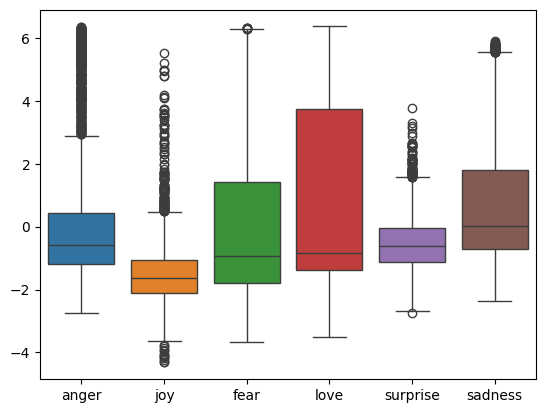

In [98]:
sns.boxplot(data=roberta_scores)

In [104]:
mooder("I'm so in love with my wife.")

Your mood appear to be love
Feeling love is the best feeling one could experience. May this long last for you and your loved one.


{'anger': -1.1483142,
 'joy': -0.69797736,
 'fear': -1.474366,
 'love': 4.7963195,
 'surprise': -0.9491314,
 'sadness': 1.3493199}

The model is performing well at recognizing the emotions of the text.

I'm now going to train a second model which is going to predict whether the text contain hate speech.

In [105]:
model.save_pretrained(
    "c:/Data_Science/IH_Notebooks/tweet_emotion_recognition", 
    safe_serialization=True  # Using safe serialization to reduce memory usage
)

In [107]:
from transformers import RobertaTokenizerFast, RobertaForSequenceClassification


# Save the model
model.save_pretrained("c:/Data_Science/IH_Notebooks/tweet_emotion_recognition", safe_serialization=True)

# Save the tokenizer
tokenizer.save_pretrained("c:/Data_Science/IH_Notebooks/tweet_emotion_recognition")


('c:/Data_Science/IH_Notebooks/tweet_emotion_recognition\\tokenizer_config.json',
 'c:/Data_Science/IH_Notebooks/tweet_emotion_recognition\\special_tokens_map.json',
 'c:/Data_Science/IH_Notebooks/tweet_emotion_recognition\\vocab.json',
 'c:/Data_Science/IH_Notebooks/tweet_emotion_recognition\\merges.txt',
 'c:/Data_Science/IH_Notebooks/tweet_emotion_recognition\\added_tokens.json',
 'c:/Data_Science/IH_Notebooks/tweet_emotion_recognition\\tokenizer.json')